# 02 Exploratory Analysis

This notebook explores sales, profit, operational timing, and customer acquisition patterns using direct pandas and plotting code.


## Import Libraries and Load Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')


In [2]:
cleaned_path = '../data/processed/cleaned_luminatech_transactions.csv'
sample_path = '../data/sample/sample_luminatech_data.csv'

if os.path.exists(cleaned_path):
    Dataset_cleaned = pd.read_csv(cleaned_path, dtype={'customer_code': str}, low_memory=False)
else:
    Dataset_cleaned = pd.read_csv(sample_path, dtype={'customer_code': str})

for col in ['accounting_date', 'invoice_date', 'order_date']:
    if col in Dataset_cleaned.columns:
        Dataset_cleaned[col] = pd.to_datetime(Dataset_cleaned[col], errors='coerce')

if 'profit' not in Dataset_cleaned.columns:
    Dataset_cleaned['profit'] = Dataset_cleaned['value_sales'] - Dataset_cleaned['value_cost']

if 'time_gap' not in Dataset_cleaned.columns:
    Dataset_cleaned['time_gap'] = (Dataset_cleaned['invoice_date'] - Dataset_cleaned['order_date']).dt.days

os.makedirs('../visuals', exist_ok=True)
Dataset_cleaned.head()


,accounting_date,fiscal_year,fiscal_month,calendar_year,calendar_month,calendar_day,company_code,customer_code,customer_district_code,item_code,...,value_price_adjustment,currency,invoice_number,line_number,invoice_date,customer_order_number,order_date,dss_update_time,profit,time_gap
0,2012-05-09,2012,11,2012,5,9,101,411800601,410,GENIE8WWWBC,...,0,AUD,2217887,1,2012-05-09,2865354,2012-05-09,49:58.7,40.2024,0
1,2012-02-16,2012,8,2012,2,16,101,361000403,300,GENIE8WWWBC,...,0,AUD,2185745,1,2012-02-16,2833515,2012-02-16,49:58.7,12.8232,0
2,2012-05-09,2012,11,2012,5,9,101,361000403,300,GENIE8WWWBC,...,0,AUD,2217807,1,2012-05-09,2864857,2012-05-08,49:58.7,14.7432,1
3,2012-05-18,2012,11,2012,5,18,101,565540415,500,GENIE8WWWBC,...,0,AUD,2222758,1,2012-05-18,2869759,2012-05-18,49:58.7,7.3716,0
4,2012-01-09,2012,7,2012,1,9,101,565540415,500,GENIE8WWWBC,...,0,AUD,2170374,1,2012-01-09,2819189,2012-01-09,49:58.7,6.4116,0


## Add District Names

District names make the charts easier to understand for business readers.


In [3]:
district_names = {
    200: 'Sydney',
    210: 'ACT/Riverina',
    300: 'Melbourne',
    310: 'Tasmania',
    400: 'Brisbane',
    410: 'Townsville',
    500: 'Adelaide',
    510: 'Darwin',
    520: 'Inlite - NZ',
    530: 'South Island - NZ',
    535: 'Central Region - NZ',
    540: 'Northern Region - NZ',
    545: 'Head Office NZ',
    600: 'Perth',
    710: 'Head Office Sales',
    720: 'Intercompany Sales'
}

Dataset_cleaned['customer_district_names'] = Dataset_cleaned['customer_district_code'].map(district_names)
Dataset_cleaned['customer_district_names'] = Dataset_cleaned['customer_district_names'].fillna(Dataset_cleaned['customer_district_code'].astype(str))


## Average Order-to-Invoice Time Gap


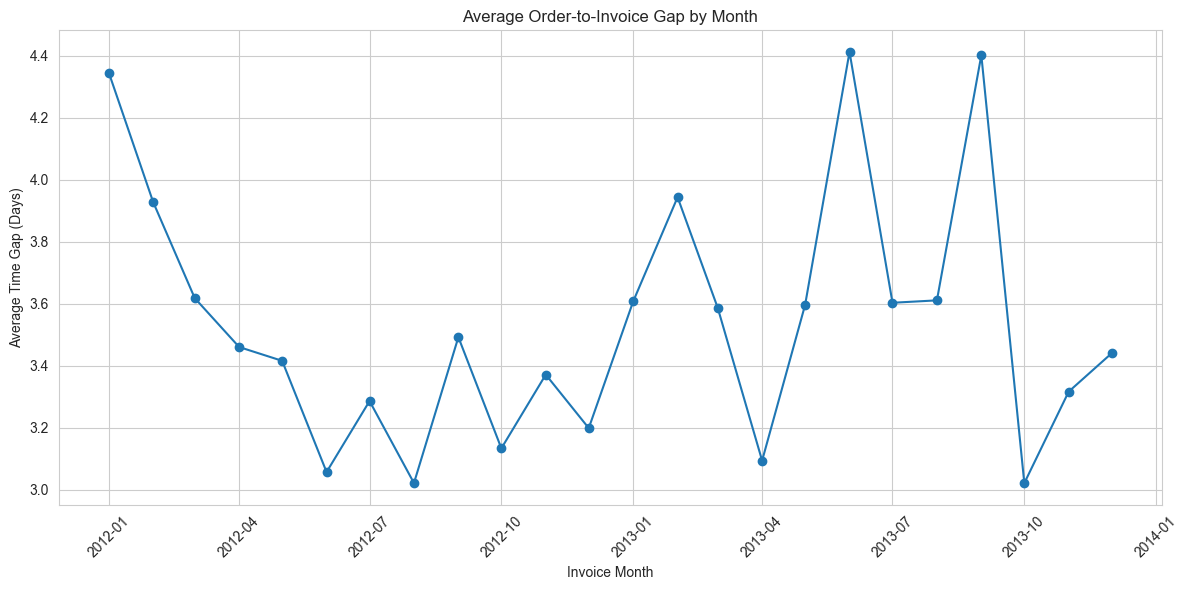

In [4]:
time_gap_avg = Dataset_cleaned.groupby(Dataset_cleaned['invoice_date'].dt.to_period('M'))['time_gap'].mean()
time_gap_avg.index = time_gap_avg.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(time_gap_avg.index, time_gap_avg.values, marker='o')
plt.title('Average Order-to-Invoice Gap by Month')
plt.xlabel('Invoice Month')
plt.ylabel('Average Time Gap (Days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/01_order_invoice_gap.png', dpi=160)
plt.show()


## Sales by District


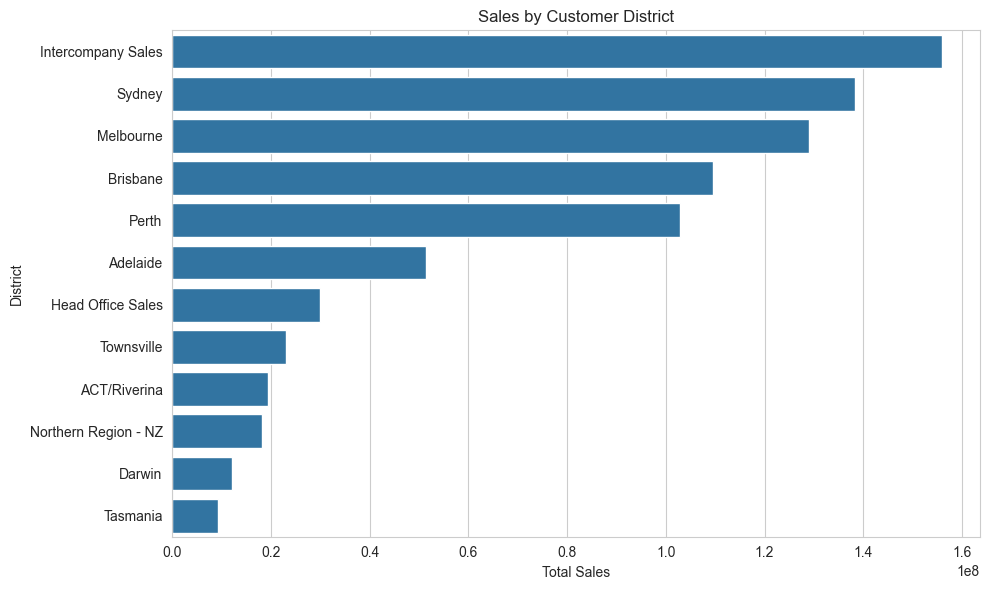

In [5]:
sales_by_district = Dataset_cleaned.groupby('customer_district_names')['value_sales'].sum().sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_district.values, y=sales_by_district.index)
plt.title('Sales by Customer District')
plt.xlabel('Total Sales')
plt.ylabel('District')
plt.tight_layout()
plt.savefig('../visuals/02_sales_by_district.png', dpi=160)
plt.show()


## Sales by Business Chain


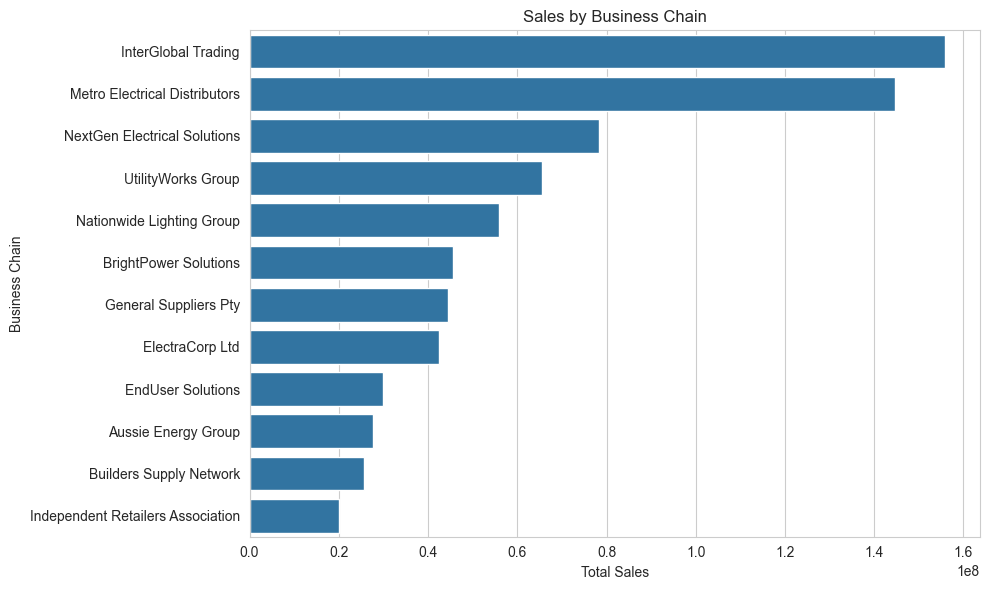

In [6]:
sales_by_chain = Dataset_cleaned.groupby('business_chain_l1_name')['value_sales'].sum().sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_chain.values, y=sales_by_chain.index)
plt.title('Sales by Business Chain')
plt.xlabel('Total Sales')
plt.ylabel('Business Chain')
plt.tight_layout()
plt.savefig('../visuals/03_sales_by_business_chain.png', dpi=160)
plt.show()


## Profit Contribution by Product Type


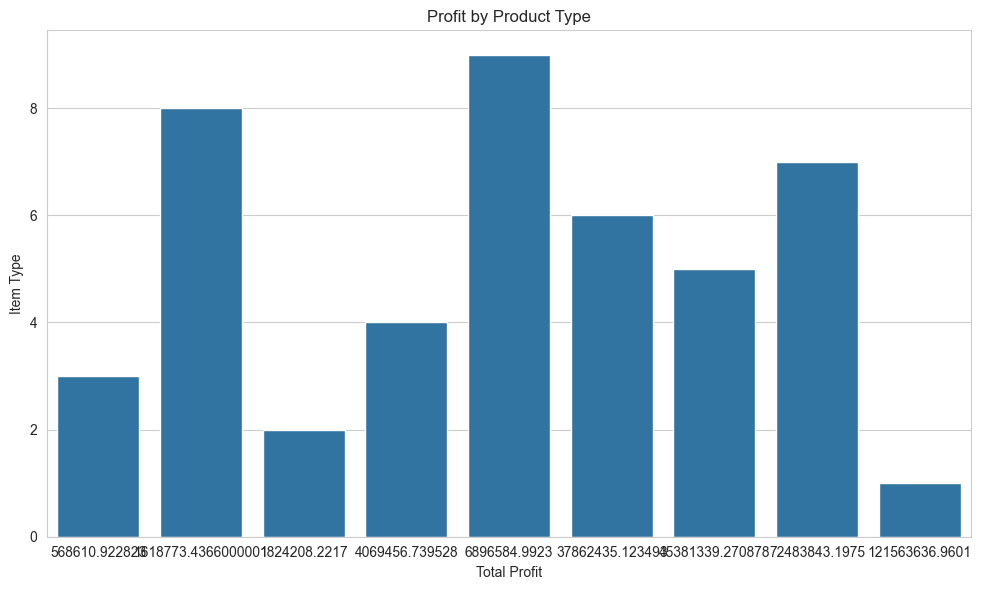

In [7]:
profit_by_product = Dataset_cleaned.groupby('item_type')['profit'].sum().sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=profit_by_product.values, y=profit_by_product.index)
plt.title('Profit by Product Type')
plt.xlabel('Total Profit')
plt.ylabel('Item Type')
plt.tight_layout()
plt.savefig('../visuals/04_profit_by_product.png', dpi=160)
plt.show()


## Profit by District Over Time


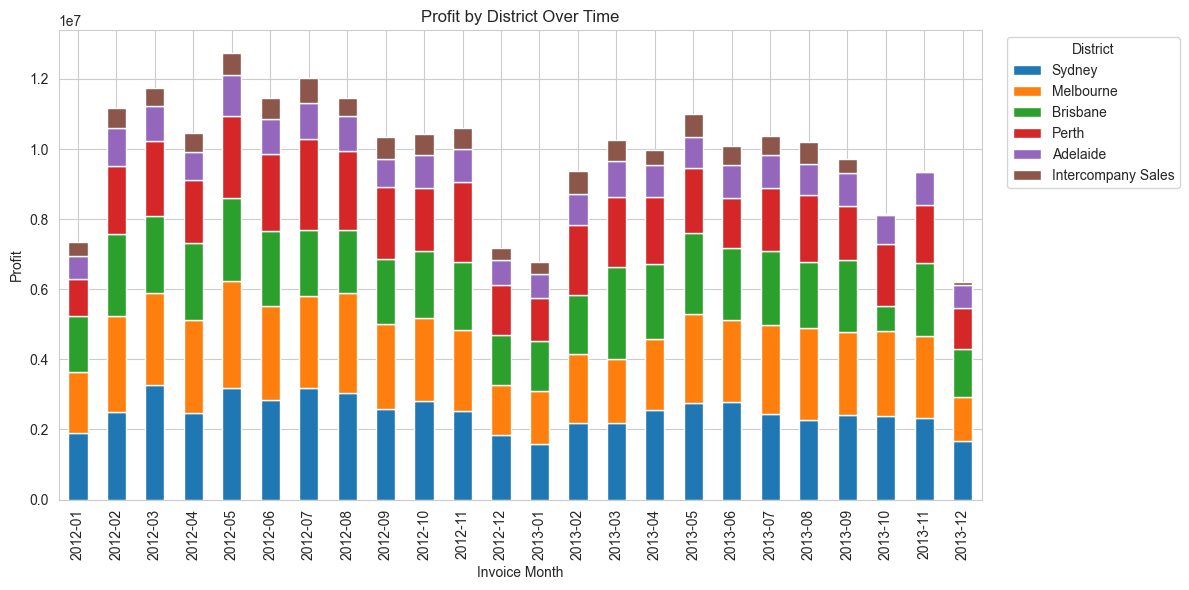

In [8]:
Dataset_cleaned['calendar_month_plot'] = Dataset_cleaned['invoice_date'].dt.to_period('M').astype(str)
profit_by_time = Dataset_cleaned.pivot_table(
    values='profit',
    index='calendar_month_plot',
    columns='customer_district_names',
    aggfunc='sum',
    fill_value=0
)

top_districts = profit_by_time.sum().sort_values(ascending=False).head(6).index
profit_by_time[top_districts].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Profit by District Over Time')
plt.xlabel('Invoice Month')
plt.ylabel('Profit')
plt.legend(title='District', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../visuals/05_profit_by_district_time.png', dpi=160)
plt.show()


## Currency and Profit Relationship


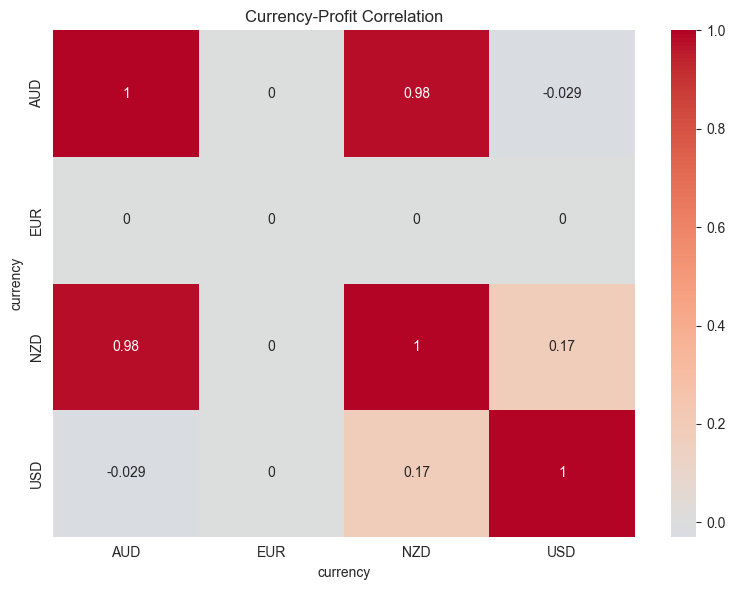

In [9]:
currency_profit = Dataset_cleaned.pivot_table(
    values='profit',
    index='fiscal_year',
    columns='currency',
    aggfunc='sum'
)

plt.figure(figsize=(8, 6))
sns.heatmap(currency_profit.corr().fillna(0), annot=True, cmap='coolwarm', center=0)
plt.title('Currency-Profit Correlation')
plt.tight_layout()
plt.savefig('../visuals/06_currency_profit_correlation.png', dpi=160)
plt.show()


## Customer Acquisition and Initial Spend


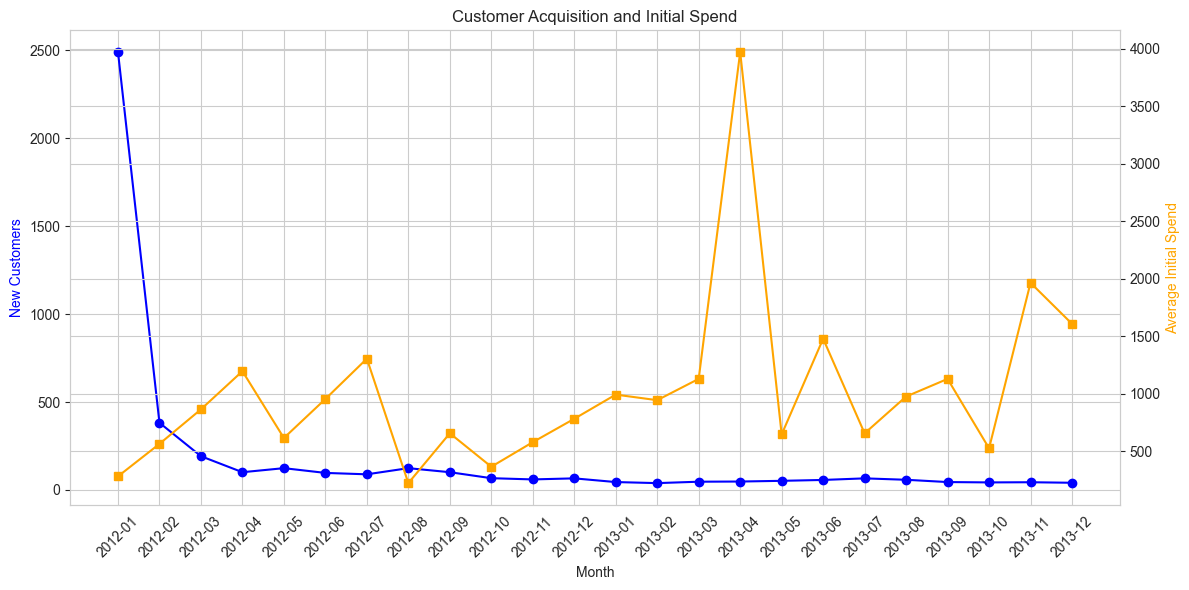

In [10]:
first_purchase = Dataset_cleaned.groupby('customer_code')['invoice_date'].min().reset_index()
first_purchase['first_purchase_month'] = first_purchase['invoice_date'].dt.to_period('M')

new_customers_monthly = first_purchase.groupby('first_purchase_month').size()
initial_purchases = Dataset_cleaned.merge(first_purchase, on=['customer_code', 'invoice_date'], how='inner')
initial_monthly_spend = initial_purchases.groupby('first_purchase_month')['value_sales'].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
x_labels = new_customers_monthly.index.astype(str)

ax1.plot(x_labels, new_customers_monthly.values, marker='o', color='blue')
ax1.set_xlabel('Month')
ax1.set_ylabel('New Customers', color='blue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(x_labels, initial_monthly_spend.reindex(new_customers_monthly.index).values, marker='s', color='orange')
ax2.set_ylabel('Average Initial Spend', color='orange')

plt.title('Customer Acquisition and Initial Spend')
plt.tight_layout()
plt.savefig('../visuals/07_customer_acquisition_initial_spend.png', dpi=160)
plt.show()
